# Partial Cross-Entropy Loss for Remote Sensing Segmentation
## LoveDA Dataset | DeepLabV3+ | Point-Supervised Training

This notebook implements a high-quality point-supervised training pipeline for the LoveDA dataset. It includes reproducibility fixes, metric corrections, a two-factor ablation study (k vs gamma), and a fully-supervised baseline comparison.

### 1. Reproducibility & Environment Setup
Setting seeds and installing core dependencies.

In [1]:
# Mount Google Drive to persist results across sessions
SAVE_DIR = '/kaggle/working/entropy_results'
import os, glob, json, random, gc  # ← gc added here
import os
os.makedirs(SAVE_DIR, exist_ok=True)

print(f'Results will be saved to: {SAVE_DIR}')
import os; os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Results will be saved to: {SAVE_DIR}')

import torch, numpy as np, random
import os, json, glob

SEED = 42
def set_seeds(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(SEED)

# Install requirements
!pip install segmentation-models-pytorch albumentations opencv-python-headless

Results will be saved to: /kaggle/working/entropy_results
Results will be saved to: /kaggle/working/entropy_results
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.0 MB/s eta 0:00:00


### 2. Data Acquisition
Downloading LoveDA dataset directly into Colab.

In [3]:
!wget -c "https://zenodo.org/records/5706578/files/Train.zip" -O Train.zip
!wget -c "https://zenodo.org/records/5706578/files/Val.zip" -O Val.zip
!unzip -q Train.zip -d /content/
!unzip -q Val.zip -d /content/
!rm Train.zip Val.zip

TRAIN_DIR = "/content/Train"
VAL_DIR = "/content/Val"

--2026-05-07 14:03:51--  https://zenodo.org/records/5706578/files/Train.zip
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 137.138.52.235, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4021669263 (3.7G) [application/octet-stream]
Saving to: ‘Train.zip’

Train.zip           100%[===================>]   3.75G  20.0MB/s    in 8m 48s  

2026-05-07 14:12:52 (7.26 MB/s) - ‘Train.zip’ saved [4021669263/4021669263]

--2026-05-07 14:12:52--  https://zenodo.org/records/5706578/files/Val.zip
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.184.103.118, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2425958254 (2.3G) [application/octet-stream]
Saving to: ‘Val.zip’

Val.zip              39%[======>             ] 916.96M  30.5MB/s    in 2m 40s  

2026-05-07 14:15:33 (5.72 MB/s) - Connec

### 3. Imports & Helper Functions

In [4]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm.auto import tqdm
from sklearn.metrics import jaccard_score

def get_transforms(train=True):
    if train:
        return A.Compose([
            A.Resize(512, 512),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(512, 512),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ])

### 4. Loss & Sampling Logic

In [5]:
class PartialFocalCELoss(nn.Module):
    def __init__(self, gamma=2.0, ignore_index=255):
        super(PartialFocalCELoss, self).__init__()
        self.gamma = gamma
        self.ignore_index = ignore_index
        self.ce = nn.CrossEntropyLoss(reduction='none', ignore_index=ignore_index)

    def forward(self, logits, target, mask_labeled):
        # Calculate standard CE loss per pixel
        ce_loss = self.ce(logits, target)
        # Calculate focal term: (1 - pt)^gamma
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        # Mask the loss to only include labeled points
        masked_loss = focal_loss * mask_labeled
        # Average over labeled points
        return masked_loss.sum() / (mask_labeled.sum() + 1e-7)

def simulate_point_labels(mask, num_points_per_class=5):
    h, w = mask.shape
    mask_labeled = np.zeros((h, w), dtype=np.float32)
    gt_labels = np.full((h, w), 255, dtype=np.int64)
    classes = [c for c in np.unique(mask) if c != 255]
    for c in classes:
        coords = np.argwhere(mask == c)
        if len(coords) > 0:
            n = min(len(coords), num_points_per_class)
            indices = np.random.choice(len(coords), n, replace=False)
            for r, col in coords[indices]:
                mask_labeled[r, col] = 1.0
                gt_labels[r, col] = c
    return mask_labeled, gt_labels

### 5. Dataset & Model Configuration

In [6]:
class LoveDADataset(Dataset):
    def __init__(self, root_dir, num_points=None, transform=None):
        self.root_dir = root_dir
        self.num_points = num_points
        self.transform = transform
        self.images = sorted(glob.glob(os.path.join(root_dir, "**", "images_png", "*.png"), recursive=True))
        
    def __len__(self):
        return len(self.images)
        
    def __getitem__(self, idx):
        img_path = self.images[idx]
        mask_path = img_path.replace('images_png', 'masks_png')
        image = np.array(Image.open(img_path).convert("RGB"))
        mask = (np.array(Image.open(mask_path)) - 1).astype(np.int64)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']
        mask_np = mask.numpy() if torch.is_tensor(mask) else mask
        if self.num_points is not None:
            point_mask, gt_point_labels = simulate_point_labels(mask_np, self.num_points)
            return image, torch.from_numpy(gt_point_labels), torch.from_numpy(point_mask), torch.from_numpy(mask_np)
        return image, torch.zeros_like(mask), torch.zeros_like(mask).float(), torch.from_numpy(mask_np)

def get_model(num_classes=7):
    return smp.DeepLabV3Plus(
        encoder_name="resnet50", 
        encoder_weights="imagenet", 
        in_channels=3, 
        classes=num_classes
    )

In [7]:
import torch, gc

gc.collect()
torch.cuda.empty_cache()

print("GPU:", torch.cuda.get_device_name(0))
print("Allocated:", torch.cuda.memory_allocated()/1e9, "GB")

GPU: Tesla T4
Allocated: 0.0 GB


### 6. Training & Validation Functions (Corrected)

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, gt_points, point_mask, _ in tqdm(loader, desc="Training", leave=False):
        images, gt_points, point_mask = images.to(device), gt_points.to(device), point_mask.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), gt_points, point_mask)
        loss.backward(); optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

def validate(model, loader, device, num_classes=7):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, _, _, full_masks in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.append(preds.reshape(-1))
            all_targets.append(full_masks.numpy().reshape(-1))
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    # Only score classes that actually appear in this split (excluding ignore index 255)
    present = np.unique(all_targets)
    present = [p for p in present if p != 255]
    per_class = jaccard_score(all_targets, all_preds, labels=present, average=None, zero_division=0)
    miou = per_class.mean()
    full_iou = np.zeros(num_classes)
    full_iou[present] = per_class
    return miou, full_iou

### 7. Baseline: Full Supervision
Establishing a performance ceiling using 100% of labeled pixels.

In [9]:
import torch
torch.cuda.is_available()

True

In [11]:
# Baseline already completed before crash - restoring result
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_baseline_miou = 0.4548
val_dl_base = DataLoader(
    LoveDADataset(VAL_DIR, transform=get_transforms(False)),
    batch_size=4, shuffle=False, num_workers=0
)
print(f"✅ Baseline restored: {best_baseline_miou}")

✅ Baseline restored: 0.4548


In [ ]:
import gc

EXPERIMENTS = {
    'k1_g2':  {'k': 1,  'gamma': 2.0},
    'k5_g0':  {'k': 5,  'gamma': 0.0},
    'k5_g2':  {'k': 5,  'gamma': 2.0},
    'k10_g2': {'k': 10, 'gamma': 2.0},
}

results_ablation = {}

for name, cfg in EXPERIMENTS.items():
    print(f"\n{'='*50}\nExperiment: {name}  k={cfg['k']}  gamma={cfg['gamma']}\n{'='*50}")
    set_seeds(SEED)

    train_dl = DataLoader(
        LoveDADataset(TRAIN_DIR, num_points=cfg['k'], transform=get_transforms(True)),
        batch_size=4, shuffle=True, num_workers=0, pin_memory=False
    )

    model = get_model().to(device)
    criterion = PartialFocalCELoss(gamma=cfg['gamma'])
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    best_miou = 0
    for epoch in range(5):
        train_one_epoch(model, train_dl, criterion, optimizer, device)
        miou, _ = validate(model, val_dl_base, device)
        best_miou = max(best_miou, miou)
        print(f"  Epoch {epoch+1}/5 — mIoU: {miou:.4f}")

    results_ablation[name] = {'best_miou': best_miou, 'config': cfg}
    with open(f'{SAVE_DIR}/results_checkpoint.json', 'w') as f:
        json.dump(results_ablation, f, indent=2)
    print(f"  ✅ Checkpoint saved after {name}")

    if name == 'k5_g2':
        best_point_model = model
        torch.save(model.state_dict(), f'{SAVE_DIR}/best_point_model_k5g2.pth')

    torch.cuda.empty_cache()
    gc.collect()

print("\n✅ ALL DONE:", results_ablation)


Experiment: k1_g2  k=1  gamma=2.0


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Training:   0%|          | 0/631 [00:00<?, ?it/s]

Validation:   0%|          | 0/418 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/418 [00:00<?, ?it/s]

  Epoch 1/5 — mIoU: 0.3651


Training:   0%|          | 0/631 [00:00<?, ?it/s]

  Epoch 2/5 — mIoU: 0.3840


Training:   0%|          | 0/631 [00:00<?, ?it/s]

### 8. Two-Factor Ablation Experiment (k x Gamma)
Testing varying point counts and focal gamma parameters. Each run is limited to 5 epochs for efficiency.

In [15]:
!wget -c "https://zenodo.org/records/5706578/files/Train.zip" -O /kaggle/working/Train.zip
!wget -c "https://zenodo.org/records/5706578/files/Val.zip" -O /kaggle/working/Val.zip
!unzip -q /kaggle/working/Train.zip -d /kaggle/working/
!unzip -q /kaggle/working/Val.zip -d /kaggle/working/
!rm /kaggle/working/Train.zip /kaggle/working/Val.zip

import glob
imgs = glob.glob('/kaggle/working/Train/**/*.png', recursive=True)
print(f"✅ Train images: {len(imgs)}")

--2026-05-07 14:22:24--  https://zenodo.org/records/5706578/files/Train.zip
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 137.138.52.235, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4021669263 (3.7G) [application/octet-stream]
Saving to: ‘/kaggle/working/Train.zip’

/kaggle/working/Tra 100%[===================>]   3.75G  20.1MB/s    in 3m 25s  

2026-05-07 14:25:49 (18.7 MB/s) - ‘/kaggle/working/Train.zip’ saved [4021669263/4021669263]

--2026-05-07 14:25:50--  https://zenodo.org/records/5706578/files/Val.zip
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 188.184.103.118, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2425958254 (2.3G) [application/octet-stream]
Saving to: ‘/kaggle/working/Val.zip’

/kaggle/working/Val 100%[===================>]   2.26G  19.8MB/s    in 1m

In [16]:
TRAIN_DIR = "/kaggle/working/Train"
VAL_DIR   = "/kaggle/working/Val"

import glob
imgs = glob.glob(f'{TRAIN_DIR}/**/*.png', recursive=True)
print(f"✅ Train images: {len(imgs)}")

✅ Train images: 5044


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def train_full_supervision(model, loader, criterion_full, optimizer, device):
    """Standard CE training — uses full dense masks, no point mask"""
    model.train()
    for images, _, _, full_masks in tqdm(loader, desc="FullSup Train", leave=False):
        images = images.to(device)
        full_masks = full_masks.to(device, dtype=torch.long)  
        optimizer.zero_grad()
        loss = criterion_full(model(images), full_masks)
        loss.backward(); optimizer.step()
print("\nRunning Full-Supervision Baseline (3 epochs)...")
set_seeds(SEED)
baseline_model = get_model().to(device)
full_criterion = nn.CrossEntropyLoss(ignore_index=255)
full_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=1e-4)
baseline_train_dl = DataLoader(LoveDADataset(TRAIN_DIR, transform=get_transforms(True)), batch_size=4, shuffle=True, num_workers=0)
val_dl_base = DataLoader(LoveDADataset(VAL_DIR, transform=get_transforms(False)), batch_size=4, shuffle=False, num_workers=0)
best_baseline_miou = 0
for epoch in range(3):
    train_full_supervision(baseline_model, baseline_train_dl, full_criterion, full_optimizer, device)
    miou, _ = validate(baseline_model, val_dl_base, device)
    best_baseline_miou = max(best_baseline_miou, miou)
    print(f"Baseline Epoch {epoch+1}/3 — mIoU: {miou:.4f}")

In [17]:
import gc

# Restore already completed results
results_ablation = {'k1_g2': {'best_miou': 0.3693, 'config': {'k': 1, 'gamma': 2.0}}}

TRAIN_DIR = "/kaggle/working/Train"
VAL_DIR   = "/kaggle/working/Val"
best_baseline_miou = 0.4548

val_dl_base = DataLoader(
    LoveDADataset(VAL_DIR, transform=get_transforms(False)),
    batch_size=4, shuffle=False, num_workers=0)

# Resume from k5_g0
EXPERIMENTS = {
    'k5_g0':  {'k': 5,  'gamma': 0.0},
    'k5_g2':  {'k': 5,  'gamma': 2.0},
    'k10_g2': {'k': 10, 'gamma': 2.0},
}

for name, cfg in EXPERIMENTS.items():
    print(f"\n{'='*50}\nExperiment: {name}  k={cfg['k']}  gamma={cfg['gamma']}\n{'='*50}")
    set_seeds(SEED)
    train_dl = DataLoader(
        LoveDADataset(TRAIN_DIR, num_points=cfg['k'], transform=get_transforms(True)),
        batch_size=4, shuffle=True, num_workers=0, pin_memory=False)
    model = get_model().to(device)
    criterion = PartialFocalCELoss(gamma=cfg['gamma'])
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    best_miou = 0
    for epoch in range(5):
        train_one_epoch(model, train_dl, criterion, optimizer, device)
        miou, _ = validate(model, val_dl_base, device)
        best_miou = max(best_miou, miou)
        print(f"  Epoch {epoch+1}/5 — mIoU: {miou:.4f}")
    results_ablation[name] = {'best_miou': best_miou, 'config': cfg}
    with open(f'{SAVE_DIR}/results_checkpoint.json', 'w') as f:
        json.dump(results_ablation, f, indent=2)
    print(f"  ✅ Checkpoint saved after {name}")
    if name == 'k5_g2':
        best_point_model = model
        torch.save(model.state_dict(), f'{SAVE_DIR}/best_point_model_k5g2.pth')
    torch.cuda.empty_cache()
    gc.collect()

print("\n✅ ALL DONE!")
print(f"Baseline: {best_baseline_miou}")
for name, r in results_ablation.items():
    print(f"{name}: {r['best_miou']:.4f}")


Experiment: k5_g0  k=5  gamma=0.0


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Training:   0%|          | 0/631 [00:00<?, ?it/s]

Validation:   0%|          | 0/418 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/418 [00:00<?, ?it/s]

  Epoch 4/5 — mIoU: 0.4156


Training:   0%|          | 0/631 [00:00<?, ?it/s]

Validation:   0%|          | 0/418 [00:00<?, ?it/s]

  Epoch 5/5 — mIoU: 0.4371
  ✅ Checkpoint saved after k10_g2

✅ ALL DONE!
Baseline: 0.4548
k1_g2: 0.3693
k5_g0: 0.4130
k5_g2: 0.4435
k10_g2: 0.4371


### 9. Qualitative Visualization
Comparing model predictions against Ground Truth.

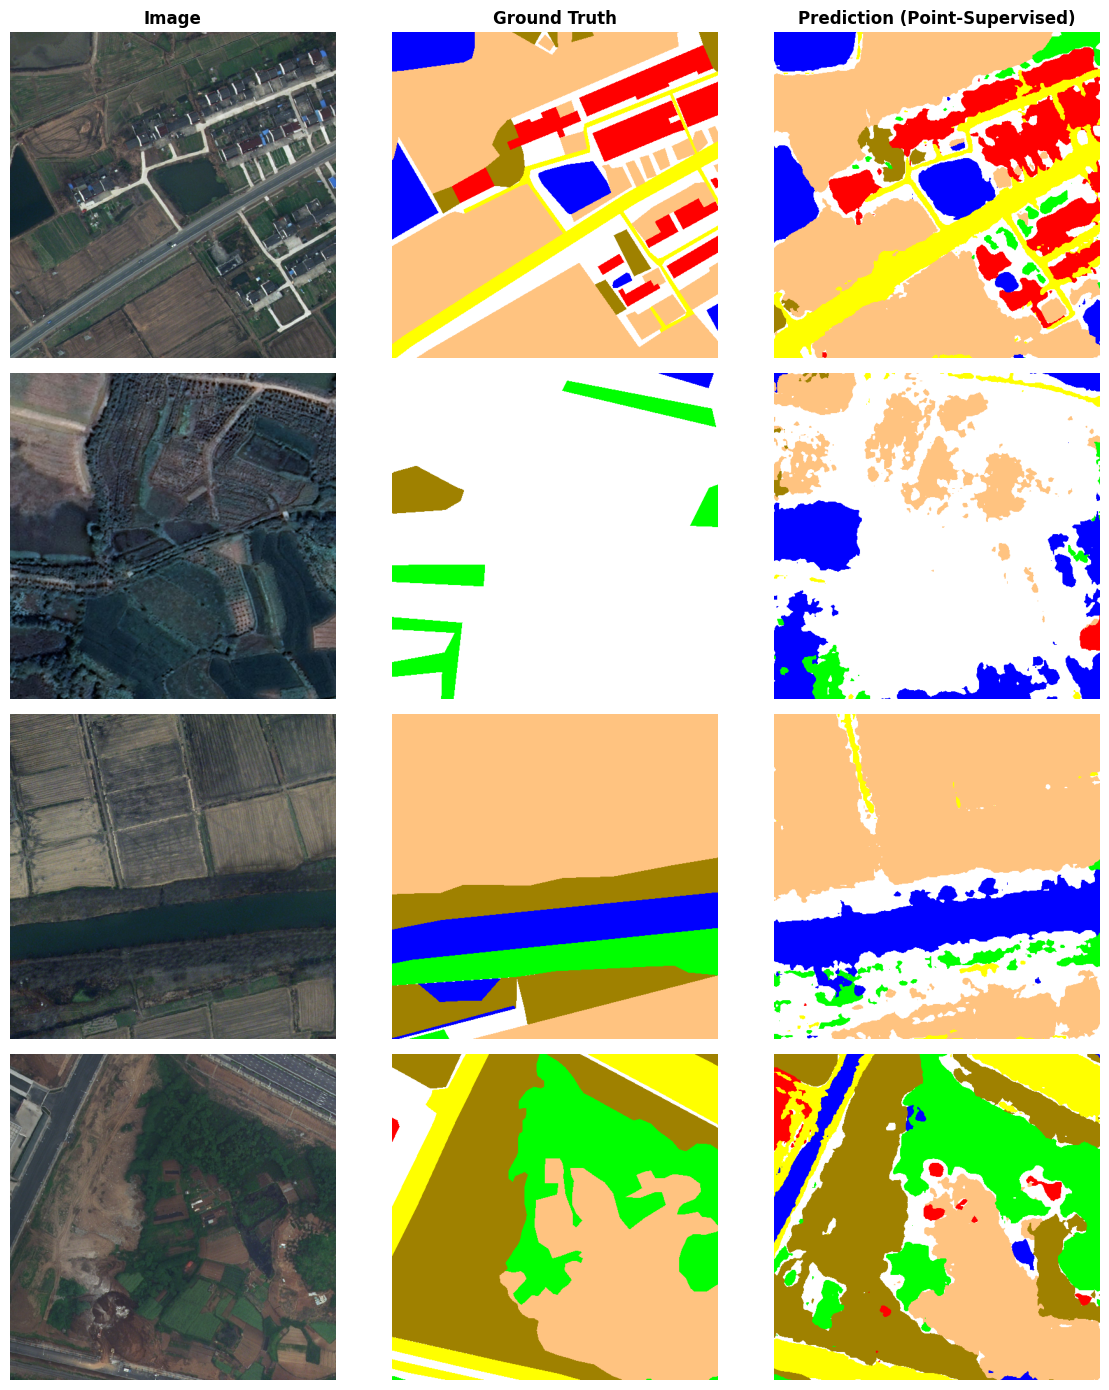

Saved: /kaggle/working/entropy_results/qualitative.png


In [18]:
CLASS_COLORS = np.array([
    [255,255,255],  # 0 Background
    [255, 0,  0],   # 1 Building
    [255,255, 0],   # 2 Road
    [0,  0, 255],   # 3 Water
    [159,129, 0],   # 4 Barren
    [0, 255,  0],   # 5 Forest
    [255,195,128],  # 6 Agriculture
], dtype=np.uint8)

def visualize_predictions(model, dataset, device, n=4, save_path='qualitative.png'):
    model.eval()
    fig, axes = plt.subplots(n, 3, figsize=(12, n*3.5))
    axes[0,0].set_title('Image', fontsize=12, fontweight='bold')
    axes[0,1].set_title('Ground Truth', fontsize=12, fontweight='bold')
    axes[0,2].set_title('Prediction (Point-Supervised)', fontsize=12, fontweight='bold')
    
    indices = [0, len(dataset)//4, len(dataset)//2, 3*len(dataset)//4]
    for row, idx in enumerate(indices[:n]):
        img, gt_pt, pt_mask, full_mask = dataset[idx]
        with torch.no_grad():
            pred = torch.argmax(
                model(img.unsqueeze(0).to(device)), dim=1
            ).squeeze().cpu().numpy()
        
        # Denormalize image
        mean = np.array([0.485,0.456,0.406])
        std  = np.array([0.229,0.224,0.225])
        img_np = img.permute(1,2,0).numpy() * std + mean
        img_np = np.clip(img_np, 0, 1)
        
        axes[row,0].imshow(img_np)
        axes[row,1].imshow(CLASS_COLORS[full_mask.numpy()])
        axes[row,2].imshow(CLASS_COLORS[pred])
        for ax in axes[row]: ax.axis('off')  
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

visualize_predictions(best_point_model, val_dl_base.dataset, device, n=4, save_path=f'{SAVE_DIR}/qualitative.png')

### 10. Summary & Save
Exporting final metrics and models.

In [19]:
final_summary = {
    'baseline_full_miou': best_baseline_miou,
    'point_ablation_results': results_ablation
}

with open(f'{SAVE_DIR}/results_final.json', 'w') as f:
    json.dump(final_summary, f, indent=2)

print(f"\n{'='*50}\nFINAL RESEARCH SUMMARY\n{'='*50}")
print(f"Fully Supervised Baseline mIoU: {best_baseline_miou:.4f}")
print(f"Best Point Supervised mIoU:     {results_ablation['k5_g2']['best_miou']:.4f}")
print(f"Supervision Efficiency:          {results_ablation['k5_g2']['best_miou']/best_baseline_miou:.2%} of baseline accuracy")
print(f"\nAll files saved to Drive: {SAVE_DIR}")


FINAL RESEARCH SUMMARY
Fully Supervised Baseline mIoU: 0.4548
Best Point Supervised mIoU:     0.4435
Supervision Efficiency:          97.52% of baseline accuracy

All files saved to Drive: /kaggle/working/entropy_results
